# Warehouse

In [4]:
import sqlite3
import pandas as pd

target_db = 'GreatOutdoors/SDM.sqlite'
target_WH_db = 'GreatOutdoors/Warehouse.sqlite'
# Connections
sdm_conn = sqlite3.connect(target_db)
dwh_conn = sqlite3.connect(target_WH_db)



## Customer Headquarters

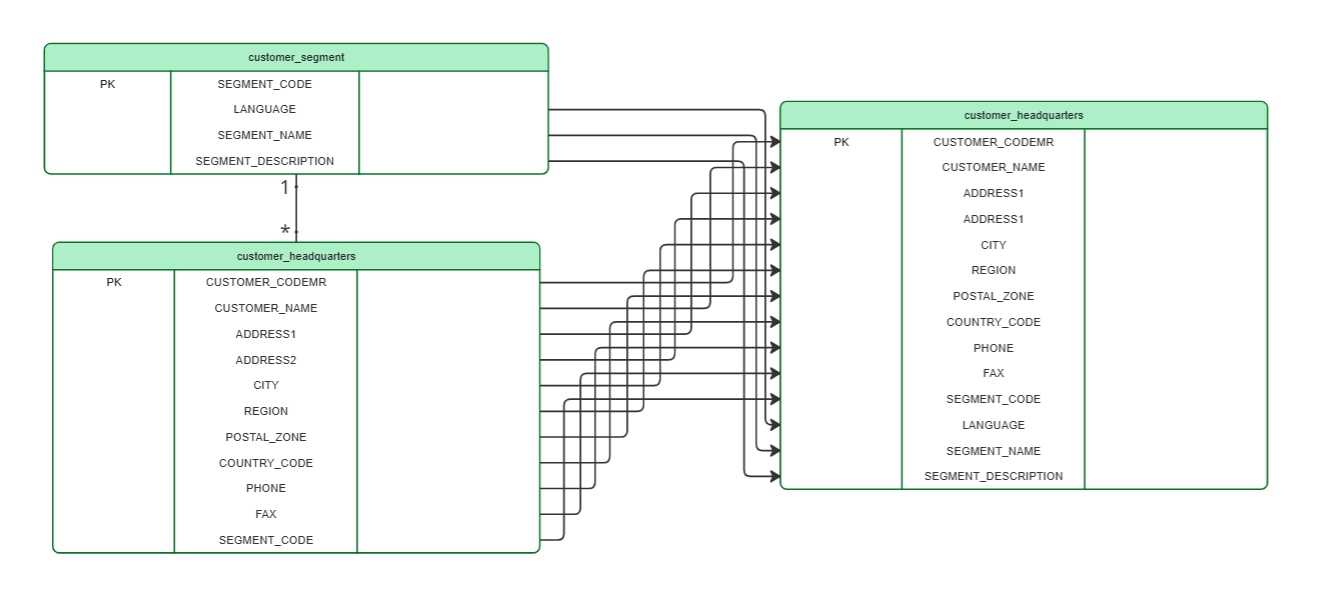

In [27]:
df_customer_segment            = pd.read_sql_query("SELECT * FROM Customer_Segment", sdm_conn)
df_customer_headquarters = pd.read_sql_query("SELECT * FROM Customer_Headquarters", sdm_conn)

df_customer_headquarters_final = pd.merge(
    df_customer_headquarters,
    df_customer_segment,
    left_on='SEGMENT_CODE',
    right_on='SEGMENT_CODE',
    how='left')
df_customer_headquarters_final = df_customer_headquarters_final[[
    'CUSTOMER_CODEMR',
    'CUSTOMER_NAME',
    'ADDRESS1',
    'ADDRESS2',
    'CITY',
    'REGION',
    'POSTAL_ZONE',
    'COUNTRY_CODE',
    'PHONE',
    'FAX',
    'SEGMENT_CODE',
    'LANGUAGE',
    'SEGMENT_NAME',
    'SEGMENT_DESCRIPTION'
]]

df_customer_headquarters_final

,CUSTOMER_CODEMR,CUSTOMER_NAME,ADDRESS1,ADDRESS2,CITY,REGION,POSTAL_ZONE,COUNTRY_CODE,PHONE,FAX,SEGMENT_CODE,LANGUAGE,SEGMENT_NAME,SEGMENT_DESCRIPTION
0,442,Morro Sports,"Rua Texeira de Freitas, 1248",6 Andar,Rio de Janeiro,RJ,20031-050,21,+55 (21) 224-7999,+55 (21) 224-0986,12,EN,Sports Store,Primarily offers a wide range of sporting goods.
1,454,"Hangzhou Superman Sports Goods Co., LTD.",59 Yang Fang Dian West,Hai Dian District,Beijing,NaN,100038,14,86-10-6252-8387,86-10-6252-8387,3,EN,Golf Shop,Primarily offers golf equipment and accessories.
2,455,"Lan King Sports Co., LTD.",No.339 Huan Shi Dong Road,NaN,Guangzhou,GuangDong,510098,14,86-20-8331-3501,86-20-8331-3501,1,EN,Outdoors Shop - Exclusive,"Primarily offers camping supplies, hiking equi..."
3,456,"China Multi-channel Sports Co., LTD.",No.318 Huan Cheng Bei Road,NaN,Hangzhou,Zhejiang,310012,14,86-571-525-2443,86-571-525-2443,7,EN,Direct Marketing,Offers a wide range of goods through mail orde...
4,457,Great Dragon Group,No.88 Zhong Shan Road,NaN,Harbin,Helong,150049,14,86-451-277-6197,86-451-277-6196,10,EN,Eyewear Store,Primarily offers prescription and fashion eyew...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,437,Esportes Grumari,"Alameda Santos, 9876",6o. Andar,São Paulo,SP,04571-010,21,+55 (11) 288-5032,+55 (11) 288-2345,5,EN,Department Store,Offers a wide range of goods.
410,438,Casa do Alpinista,"Rua Machado de Assis, 1987",2o. Andar,Porto Alegre,RS,55230-333,21,+55 (51) 333-4587,+55 (51) 333-7777,11,EN,Sports Store - Exclusive,Primarily offers a wide range of sporting good...
411,439,Mega Shop do Esporte,"Av. Presidente Wilson, 9999",10 Andar,Rio de Janeiro,RJ,20031-050,21,+55 (21) 332-5509,+55 (21) 332-9999,8,EN,Warehouse Store,Offers a wide range of goods in a large wareho...
412,440,Esportópolis,"Rua Estados Unidos, 998",Térreo,São Paulo,SP,05120-900,21,+55 (11) 878-2275,+55 (11) 878-2387,8,EN,Warehouse Store,Offers a wide range of goods in a large wareho...


In [36]:
import sqlite3
import pandas as pd

# 1. ALWAYS re-open the connection at the start of the test cell
dwh_conn = sqlite3.connect(target_WH_db) # Double check your filename!

try:
    # Read the current state of the Warehouse
    df_dwh = pd.read_sql("SELECT * FROM Customer_Headquarters", dwh_conn)
    df_customer_headquarters_final.columns = df_customer_headquarters_final.columns.str.lower()
    # 2. DETECT NEW ROWS
    new_rows = df_customer_headquarters_final[~df_customer_headquarters_final['customer_codemr'].isin(df_dwh['customer_codemr'])]

    # 3. DETECT CHANGES (Compare names as well now!)
    comparison = pd.merge(
        df_customer_headquarters_final, 
        df_dwh, 
        on = 'customer_codemr', 
        suffixes=('_src', '_dwh')
    )

    # We check if Name OR Address OR Supplier Name changed
    changed_mask = (comparison['customer_name_src'] != comparison['customer_name_dwh']) | \
                   (comparison['address1_src'] != comparison['address1_dwh']) | \
                   (comparison['address2_src'] != comparison['address2_dwh']) | \
                   (comparison['city_src'] != comparison['city_dwh']) | \
                   (comparison['region_src'] != comparison['region_dwh']) | \
                   (comparison['postal_zone_src'] != comparison['postal_zone_dwh']) | \
                   (comparison['country_code_src'] != comparison['country_code_dwh']) | \
                   (comparison['phone_src'] != comparison['phone_dwh']) | \
                   (comparison['fax_src'] != comparison['fax_dwh']) | \
                   (comparison['segment_code_src'] != comparison['segment_code_dwh']) | \
                   (comparison['language_src'] != comparison['language_dwh']) | \
                   (comparison['segment_name_src'] != comparison['segment_name_dwh']) | \
                   (comparison['segment_description_src'] != comparison['segment_description_dwh'])

    changed_rows = comparison[changed_mask]

    # --- 4. THE LOAD ---
    if not new_rows.empty:
        new_rows.to_sql('Customer_Headquarters', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new customer_headquarters.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        for _, row in changed_rows.iterrows():
            # Update the DWH with the new 'naam'
            sql = """
                UPDATE Customer_Headquarters 
                SET customer_name = ?, address1 = ?, address2 = ?, city = ?, region = ?, postal_zone = ?, country_code = ?,
                phone = ?, fax = ?, segment_code = ?, language = ?, segment_name = ?, segment_description = ?
                WHERE customer_codemr = ?
            """
            cursor.execute(sql, (row['customer_name_src'],  row['address1_src'], row['address2_src'], row['city_src'], row['region_src'], row['postal_zone_src'],
                                row['country_code_src'], row['phone_src'], row['fax_src'], row['segment_code_src'], row['language_src'],
                                row['segment_name_src'], row['segment_description_src'], row['customer_codemr']))
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} rows (SCD Type 1).")
    else:
        print("ℹ️ No changes detected between SDM and DWH.")

finally:
    # 5. Close it so the file isn't 'locked' for other programs (like DB Browser)
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 414 new customer_headquarters.
ℹ️ No changes detected between SDM and DWH.
🔌 Connection closed safely.


## Sales Demographic

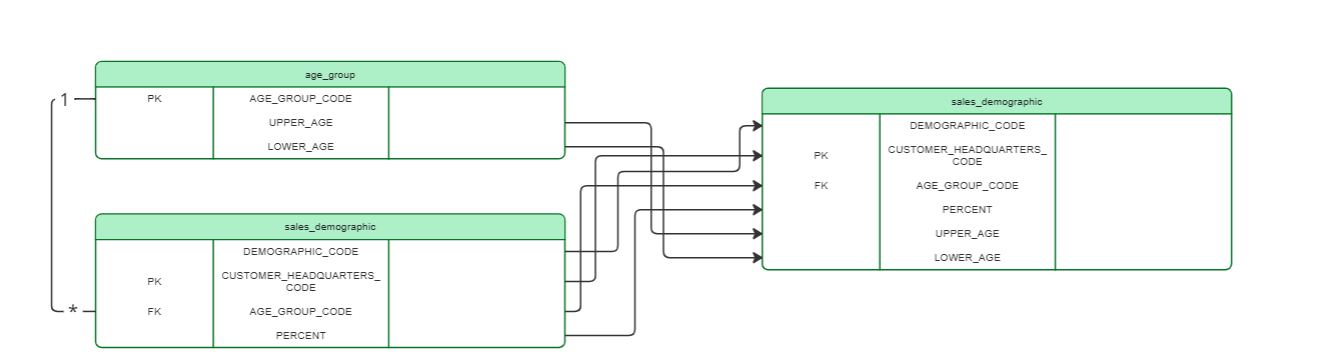

In [23]:
df_age_group            = pd.read_sql_query("SELECT * FROM Age_Group", sdm_conn)
df_sales_demographic = pd.read_sql_query("SELECT * FROM Sales_Demographic", sdm_conn)

df_sales_demographic_final = pd.merge(
    df_sales_demographic,
    df_age_group,
    left_on='AGE_GROUP_CODE',
    right_on='AGE_GROUP_CODE',
    how='left')
df_sales_demographic_final = df_sales_demographic_final[[
    'DEMOGRAPHIC_CODE',
    'CUSTOMER_CODEMR',
    'SALES_PERCENT',
    'LOWER_AGE',
    'UPPER_AGE'
]]

df_sales_demographic_final

,DEMOGRAPHIC_CODE,CUSTOMER_CODEMR,SALES_PERCENT,LOWER_AGE,UPPER_AGE
0,2475,405,25,41,50
1,2476,405,23,51,60
2,2477,405,24,61,70
3,2478,412,2,0,20
4,2479,412,4,21,30
...,...,...,...,...,...
2479,2470,627,10,51,60
2480,2471,627,0,61,70
2481,2472,405,0,0,20
2482,2473,405,6,21,30


In [ ]:
import sqlite3
import pandas as pd

# 1. ALWAYS re-open the connection at the start of the test cell
dwh_conn = sqlite3.connect(target_WH_db) # Double check your filename!

try:
    # Read the current state of the Warehouse
    df_dwh = pd.read_sql("SELECT * FROM Sales_Demographic", dwh_conn)
    df_sales_demographic_final.columns = df_sales_demographic_final.columns.str.lower()


    # 2. DETECT NEW ROWS
    new_rows = df_sales_demographic_final[~df_sales_demographic_final['demographic_code'].isin(df_dwh['demographic_code'])]

    # 3. DETECT CHANGES (Compare names as well now!)
    comparison = pd.merge(
        df_sales_demographic_final, 
        df_dwh, 
        on='demographic_code', 
        suffixes=('_src', '_dwh')
    )

    # We check if Name OR Address OR Supplier Name changed
    changed_mask = (comparison['customer_codemr_src'] != comparison['customer_codemr_dwh']) | \
                   (comparison['sales_percent_src'] != comparison['sales_percent_dwh']) | \
                   (comparison['upper_age_src'] != comparison['upper_age_dwh']) | \
                   (comparison['lower_age_src'] != comparison['lower_age_dwh'])

    changed_rows = comparison[changed_mask]

    # --- 4. THE LOAD ---
    if not new_rows.empty:
        new_rows.to_sql('Sales_Demographic', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new sales_demographic.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        for _, row in changed_rows.iterrows():
            # Update the DWH with the new 'naam'
            sql = """
                UPDATE Sales_Demographic 
                SET customer_codemr = ?, sales_percent = ?, upper_age = ?, lower_age = ?
                WHERE demographic_code = ?
            """
            cursor.execute(sql, (row['customer_codemr_src'],  row['sales_percent_src'], row['upper_age_src'], row['lower_age_src'], row['demographic_code']))
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} rows (SCD Type 1).")
    else:
        print("ℹ️ No changes detected between SDM and DWH.")

finally:
    # 5. Close it so the file isn't 'locked' for other programs (like DB Browser)
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 2484 new sales_demographic.
ℹ️ No changes detected between SDM and DWH.
🔌 Connection closed safely.


## Customer

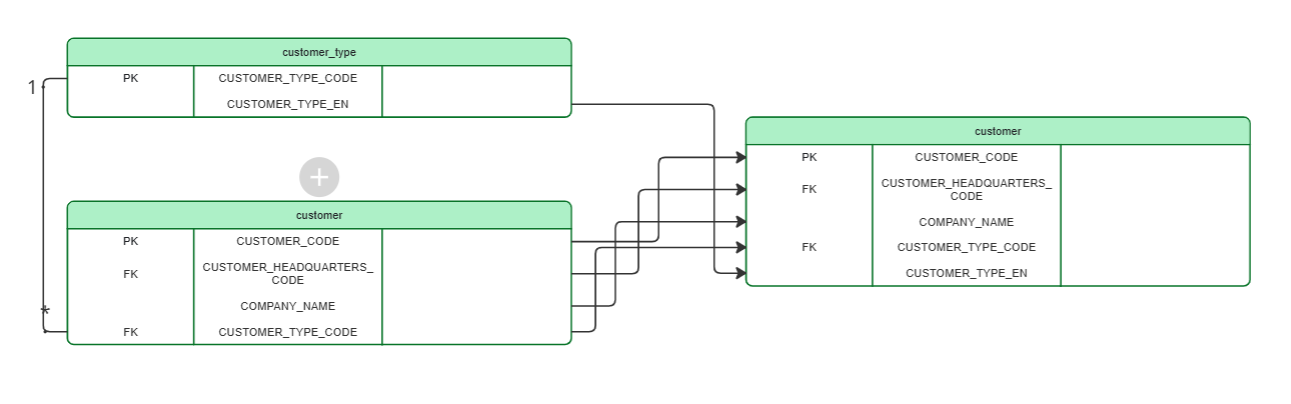

In [38]:
df_customer_type = pd.read_sql_query("SELECT * FROM Customer_Type", sdm_conn)
df_customer = pd.read_sql_query("SELECT * FROM Customer", sdm_conn)

df_customer_final = pd.merge(
    df_customer,
    df_customer_type,
    left_on='CUSTOMER_TYPE_CODE',
    right_on='CUSTOMER_TYPE_CODE',
    how='left')
df_customer_final = df_customer_final[[
    'CUSTOMER_CODE',
    'CUSTOMER_CODEMR',
    'CUSTOMER_TYPE_CODE',
    'COMPANY_NAME',
    'CUSTOMER_TYPE_EN'
]]

df_customer_final

,CUSTOMER_CODE,CUSTOMER_CODEMR,CUSTOMER_TYPE_CODE,COMPANY_NAME,CUSTOMER_TYPE_EN
0,1,NaN,5,ActiForme,Equipment Rental Store
1,15,234,1,SportsClub,Golf Shop
2,23,229,3,Anapurna,Direct Marketing
3,32,230,4,Cordages Discount,Warehouse Store
4,33,228,6,Altitudes extrêmes,Outdoors Shop
...,...,...,...,...,...
104,193,428,3,Allo Allo,Direct Marketing
105,194,429,6,Caravanserai,Outdoors Shop
106,209,415,2,Ausrüstungshaus Globetrotter,Department Store
107,210,NaN,1,Golfer-Paradies,Golf Shop


In [39]:
import sqlite3
import pandas as pd

# 1. ALWAYS re-open the connection at the start of the test cell
dwh_conn = sqlite3.connect(target_WH_db) # Double check your filename!

try:
    # Read the current state of the Warehouse
    df_dwh = pd.read_sql("SELECT * FROM Customer", dwh_conn)
    df_customer_final.columns = df_customer_final.columns.str.lower()


    # 2. DETECT NEW ROWS
    new_rows = df_customer_final[~df_customer_final['customer_code'].isin(df_dwh['customer_code'])]

    # 3. DETECT CHANGES (Compare names as well now!)
    comparison = pd.merge(
        df_customer_final, 
        df_dwh, 
        on='customer_code', 
        suffixes=('_src', '_dwh')
    )

    # We check if Name OR Address OR Supplier Name changed
    changed_mask = (comparison['customer_codemr_src'] != comparison['customer_codemr_dwh']) | \
                   (comparison['customer_type_code_src'] != comparison['customer_type_code_dwh']) | \
                   (comparison['company_name_src'] != comparison['company_name_dwh']) | \
                   (comparison['customer_type_en_src'] != comparison['customer_type_en_dwh'])

    changed_rows = comparison[changed_mask]

    # --- 4. THE LOAD ---
    if not new_rows.empty:
        new_rows.to_sql('Customer', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new customer.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        for _, row in changed_rows.iterrows():
            # Update the DWH with the new 'naam'
            sql = """
                UPDATE Customer 
                SET customer_codemr = ?, customer_type_code = ?, company_name = ?, customer_type_en = ?
                WHERE demographic_code = ?
            """
            cursor.execute(sql, (row['customer_codemr_src'],  row['customer_type_code_src'], row['company_name_src'], row['customer_type_en_src'], row['customer_code']))
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} rows (SCD Type 1).")
    else:
        print("ℹ️ No changes detected between SDM and DWH.")

finally:
    # 5. Close it so the file isn't 'locked' for other programs (like DB Browser)
    dwh_conn.close()
    print("🔌 Connection closed safely.")

🔌 Connection closed safely.


KeyError: 'customer_type_code_src'